<div class="alert alert-block alert-warning">
Baise Variance Treade off
</div>

In [71]:
# importing numpy and pandas
import numpy as np 
import pandas as pd 


# Scikit_Learn for fitting models
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# For ploting 
import matplotlib
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline 

# Fixing Default Parameters
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.titlesize'] = 15
matplotlib.rcParams['figure.figsize'] = [8,6] 

import warnings 
warnings.filterwarnings('ignore')

# Data Generation For Palynomial Regression

In [72]:
np.random.seed(42) # to fix the output of the random num generator in the code 

# The true generator function 
def true_gen(x):
    y =  np.sin(2* np.pi * x) 
    return y 

x = np.sort(np.random.rand(120))
y = true_gen(x) + 0.1*np.random.randn(len(x)) # Adding noise in the data generated 
print(x.shape, y.shape)
x,y

(120,) (120,)


(array([0.00552212, 0.02058449, 0.02541913, 0.03142919, 0.03438852,
        0.04522729, 0.04645041, 0.05808361, 0.06355835, 0.06505159,
        0.07404465, 0.07455064, 0.07697991, 0.0884925 , 0.09767211,
        0.10789143, 0.11586906, 0.11959425, 0.12203823, 0.13949386,
        0.14092422, 0.15599452, 0.15601864, 0.16122129, 0.17052412,
        0.18182497, 0.18340451, 0.18485446, 0.18657006, 0.19598286,
        0.19871568, 0.19967378, 0.21233911, 0.22879817, 0.24929223,
        0.25877998, 0.27134903, 0.28093451, 0.28975145, 0.29122914,
        0.29214465, 0.30424224, 0.30461377, 0.31098232, 0.31171108,
        0.31435598, 0.32518332, 0.32533033, 0.33089802, 0.35675333,
        0.35846573, 0.36636184, 0.37454012, 0.38867729, 0.41038292,
        0.42754102, 0.43194502, 0.44015249, 0.45606998, 0.47221493,
        0.4937956 , 0.49517691, 0.50857069, 0.51423444, 0.52006802,
        0.52273283, 0.52475643, 0.53934224, 0.54269608, 0.54671028,
        0.5612772 , 0.59241457, 0.59789998, 0.59

In [73]:
# Random indices for creating trainging and testing data set ( help to maintain iid assumption)
random_ind = np.random.choice(list(range(120)), size = 120, replace=False)
xt = x[random_ind] 
yt = y[random_ind] 

# Training and testing observations 
train = xt[:int(0.7 * len(x))] 
test = xt[int(0.7 * len(x)):]

y_train = yt[:int(0.7 * len(y))]
y_test = yt[int(0.7 * len(y)):]

# Model the true curve 
x_linspace = np.linspace(0, 1, 1000) 
y_true = true_gen(x_linspace) 


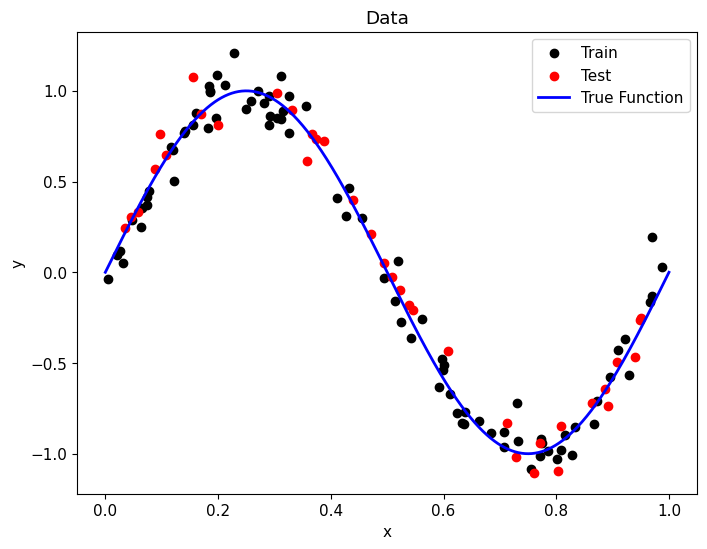

In [74]:
# Visualize Observations and true curv 
plt.scatter(train, y_train, color='black', label = 'Train'); 
plt.scatter(test, y_test, color='red', label = 'Test') 
plt.plot(x_linspace, y_true, 'b-' , linewidth = 2, label = 'True Function' ) 
plt.legend() 
plt.xlabel('x'); plt.ylabel('y'); plt.title('Data'); 

In [75]:
def fit_poly(train, y_train, test, y_test, degree, plot='Train', return_scores= False):
    # Create a polynomial transformation of features 
    features = PolynomialFeatures(degree = degree, include_bias=False) 

    # Reshape training features for use in scikit-learn and transform features 
    train = train.reshape((-1,1)) 
    """
    (-1,1) => to convrt a vectored data in a matrix 
    """
    train_trans = features.fit_transform(train) 

    # Create the linear regression model and train 
    model = LinearRegression()
    model.fit(train_trans, y_train) 

    # Training predictions and error 
    train_predicted = model.predict(train_trans) 
    training_error = mean_squared_error(y_train, train_predicted) 

    # Format the features 
    test = test.reshape((-1,1)) 
    test_trans = features.transform(test) 

    # Test set prediction and error 
    test_predictions = model.predict(test_trans) 
    test_error = mean_squared_error(y_test, test_predictions) 

    # Finding the model curve and the trie curve 
    x_curve = np.linspace(0,1,100) 
    x_curve = x_curve.reshape((-1,1)) 
    x_curve_trans = features.transform(x_curve) 

    # Model curve 
    model_curve = model.predict(x_curve_trans) 

    # True curve 
    y_true_curve = true_gen(x_curve[:,0]) 

    # Plot observations, true function and model predicted function 
    if plot == 'Train' or plot == 'train':
        plt.scatter(train[:,0], y_train, color='black', label = 'Observations'); 
        plt.plot(x_curve[:,0], y_true_curve, linewidth =4, label = 'True Function') 
        plt.plot(x_curve[:,0], model_curve, linewidth = 4, label = 'Model Function' ) 
        plt.legend() 
        plt.xlabel('x'); plt.ylabel('y')
        plt.ylim(-1, 1.5); plt.xlim(0, 1); 
        plt.title('{} Degree Model on Training Data'.format(degree)) 
        plt.show() 
    elif plot == 'test' :
        # plot the test prediction 
        plt.scatter(test[:,0], y_test, color='black', label = 'Test Observations'); 
        plt.plot(x_curve[:,0], y_true_curve, linewidth =4, label = 'True Function') 
        plt.scatter(test[:,0], test_predictions, color='red', label = 'Test Prediction' ) 
        plt.legend() 
        plt.xlabel('x'); plt.ylabel('y')
        plt.ylim(-1, 1.5); plt.xlim(0, 1); 
        plt.title('{} Degree Model on Testing Data'.format(degree)) 
        plt.show() 

    # Return the metrics and coefficients 
    if return_scores:
        return training_error, test_error, model.coef_

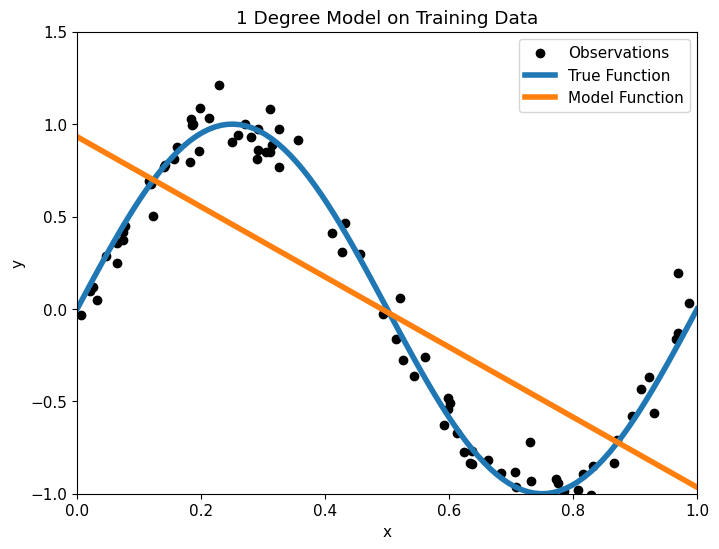

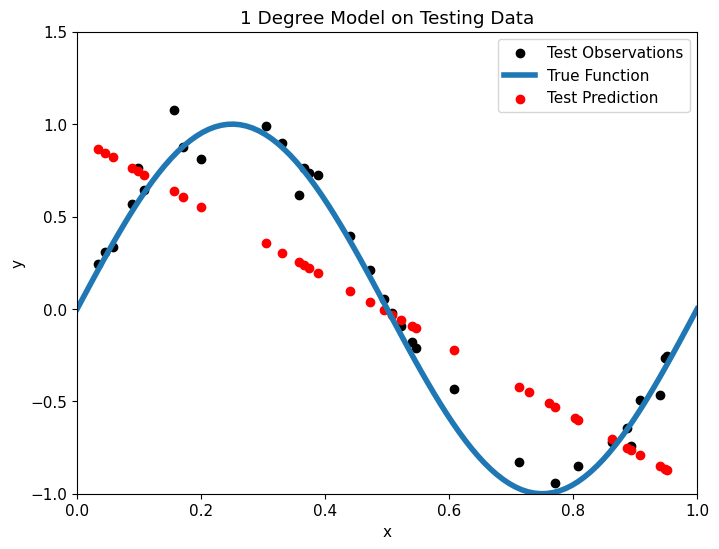

In [76]:
fit_poly(train, y_train, test, y_test, degree = 1, plot = 'train') 
fit_poly(train, y_train, test, y_test, degree = 1, plot = 'test')

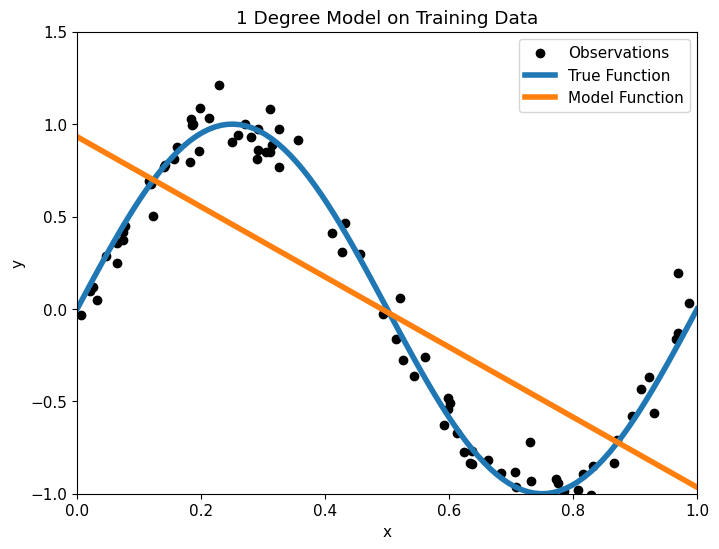

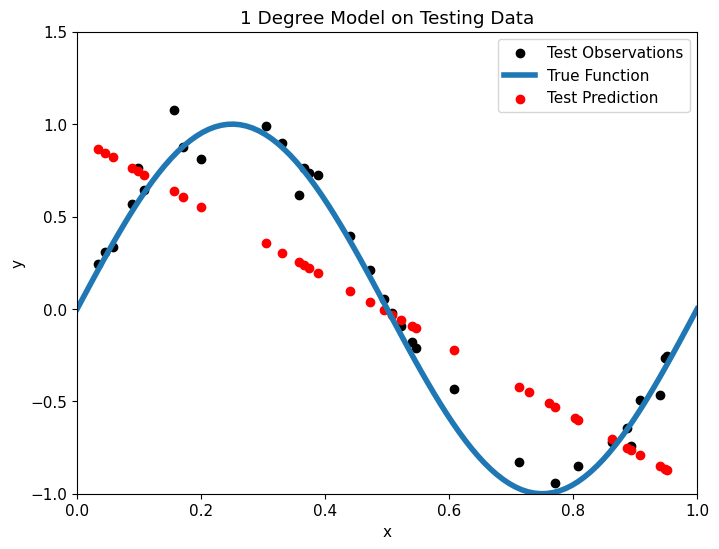

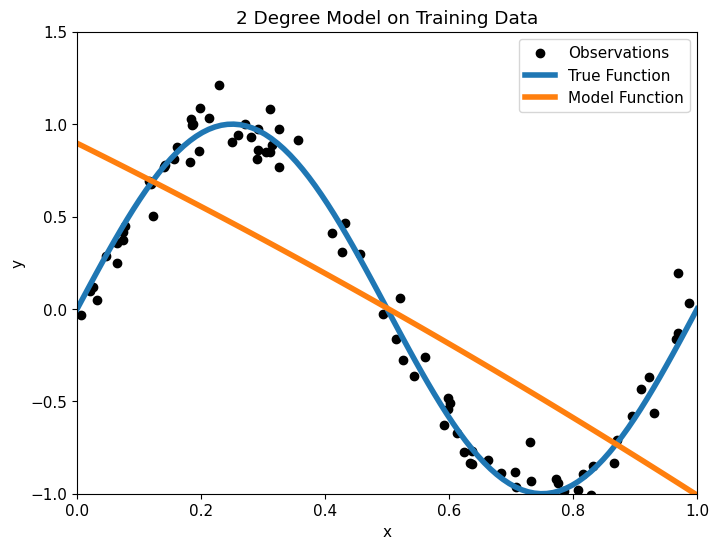

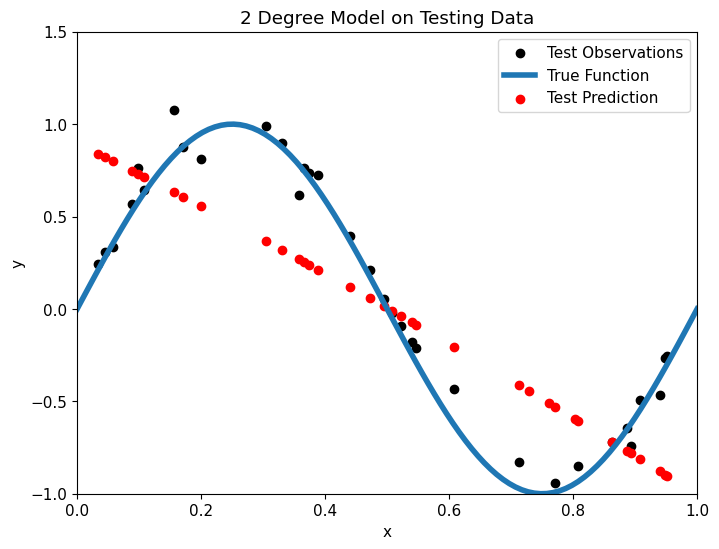

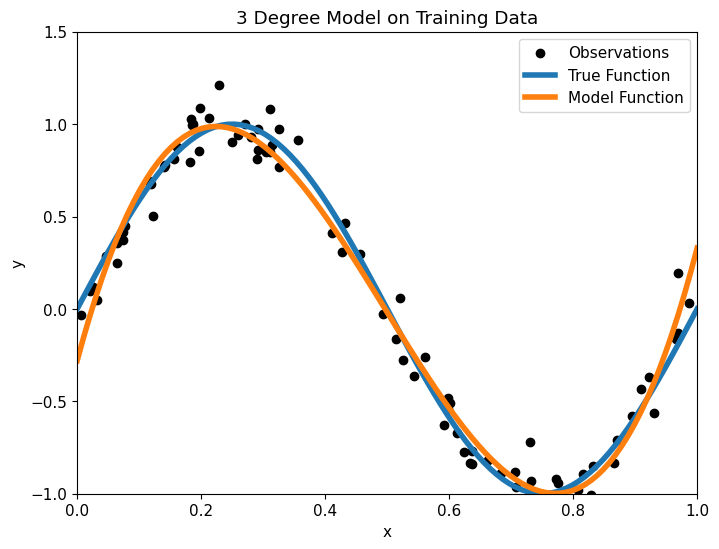

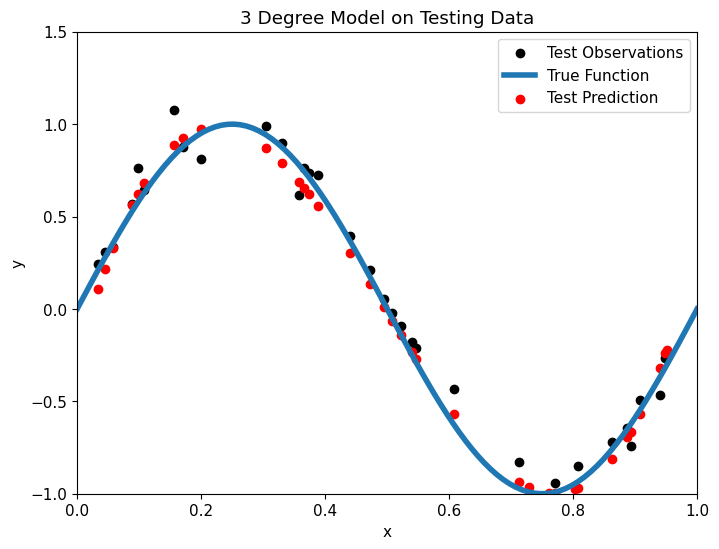

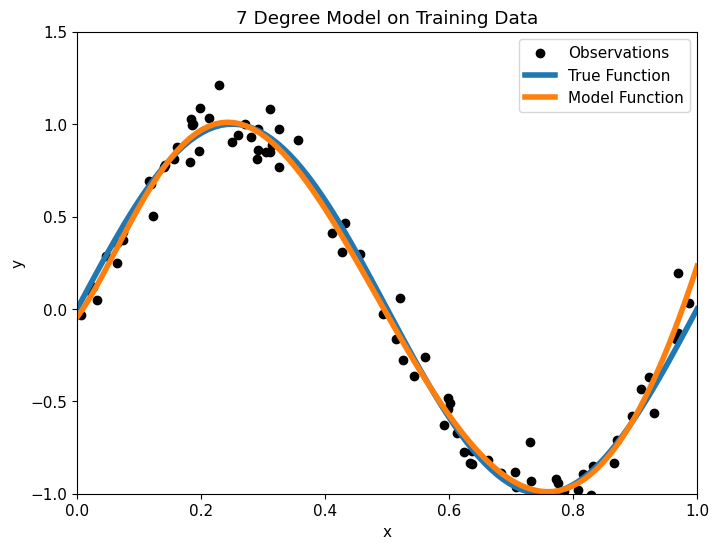

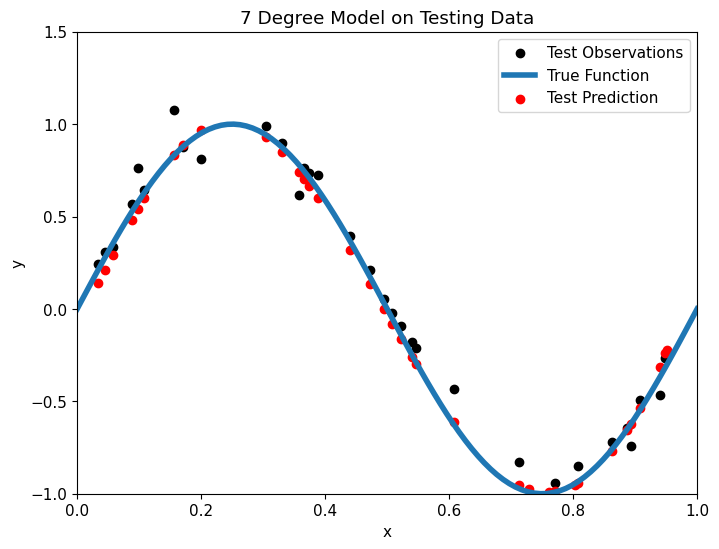

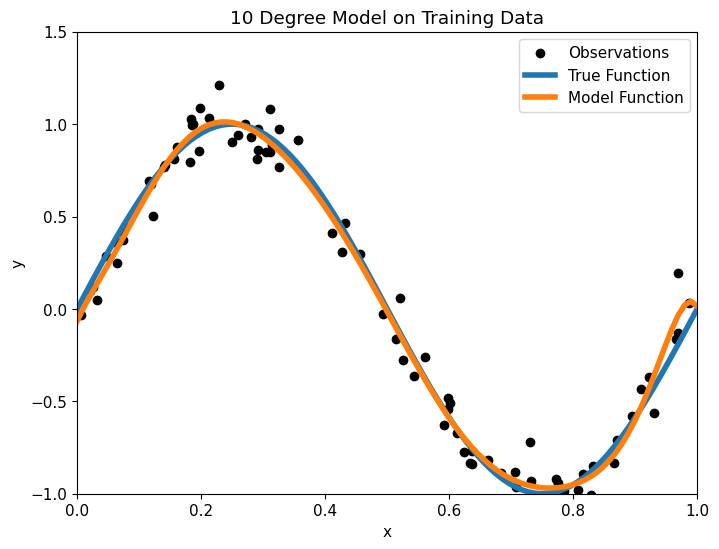

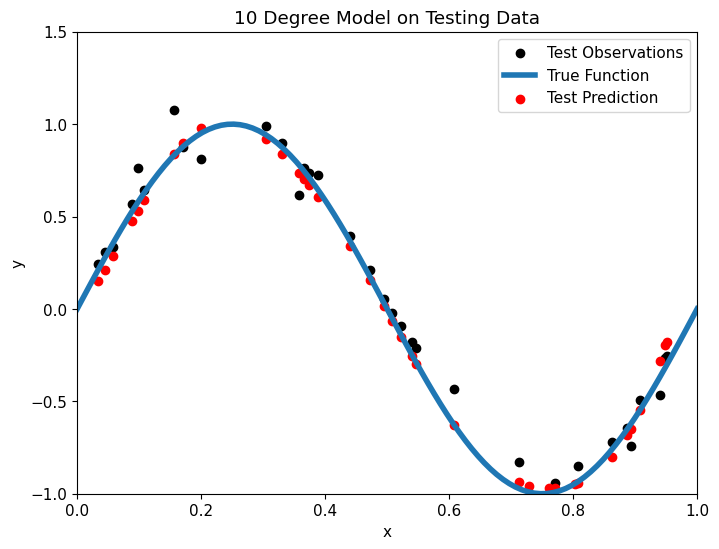

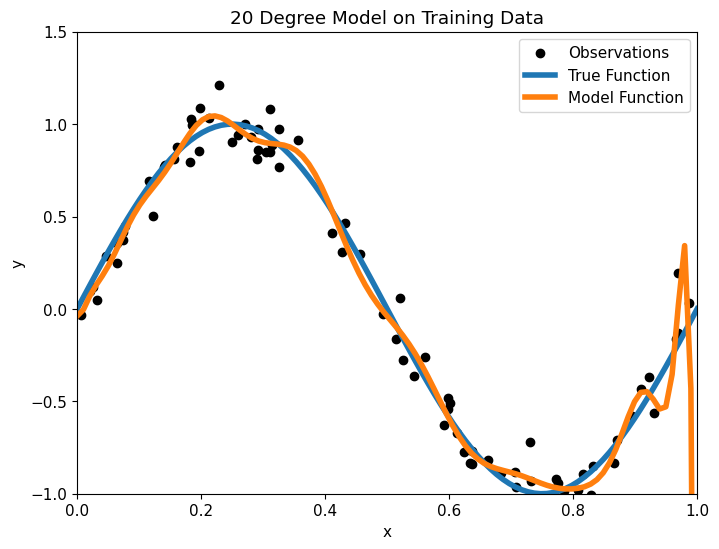

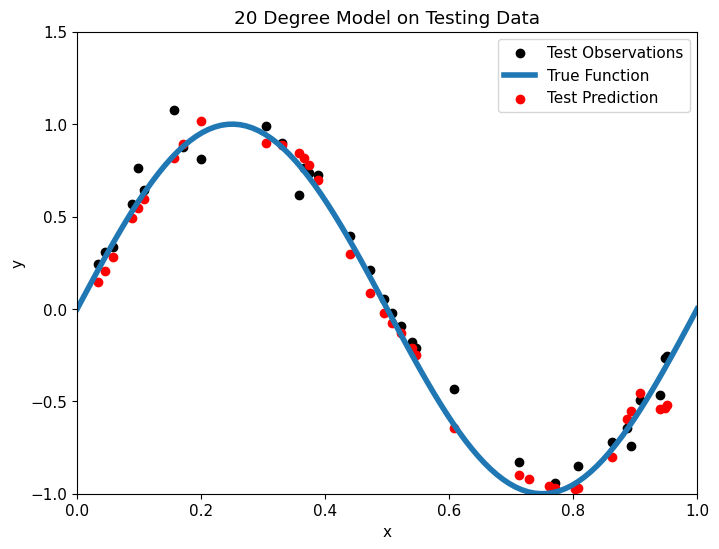

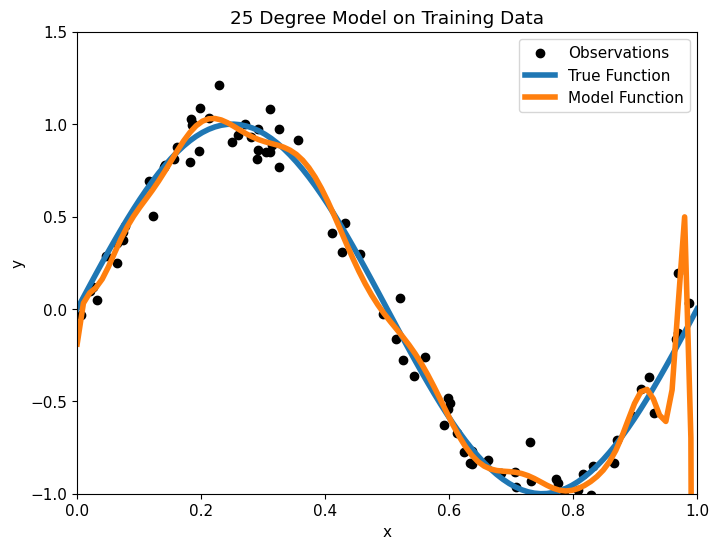

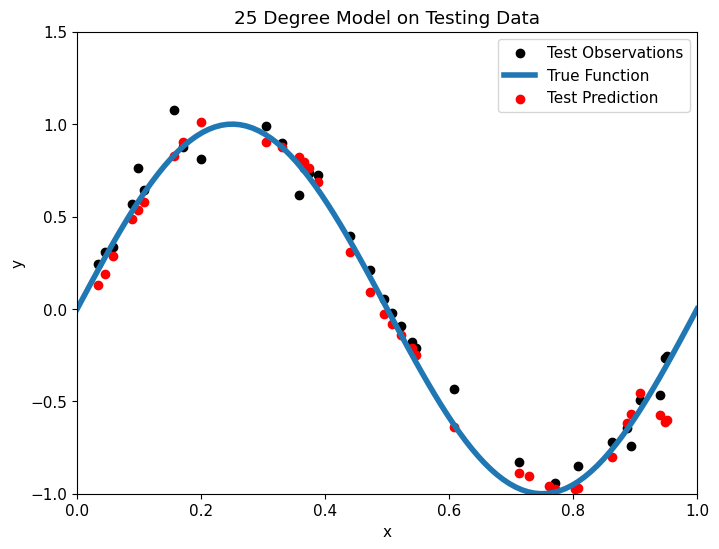

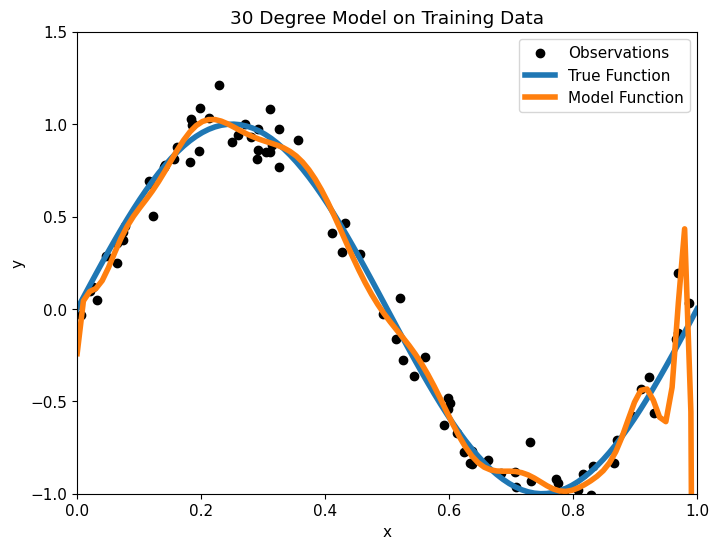

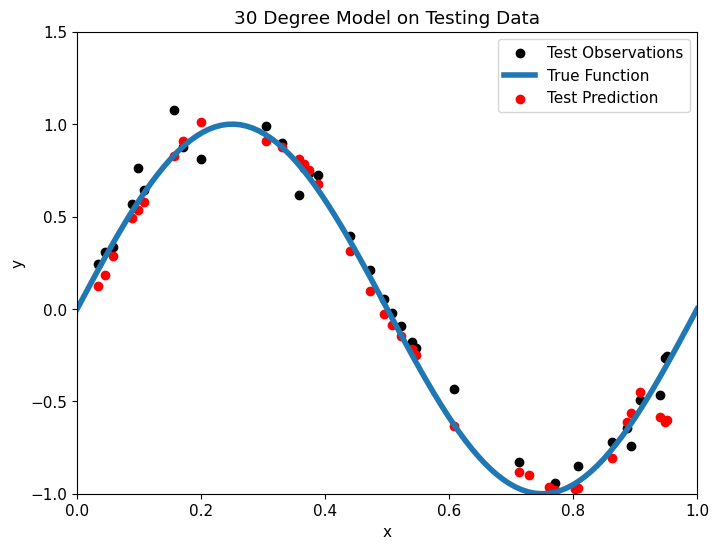

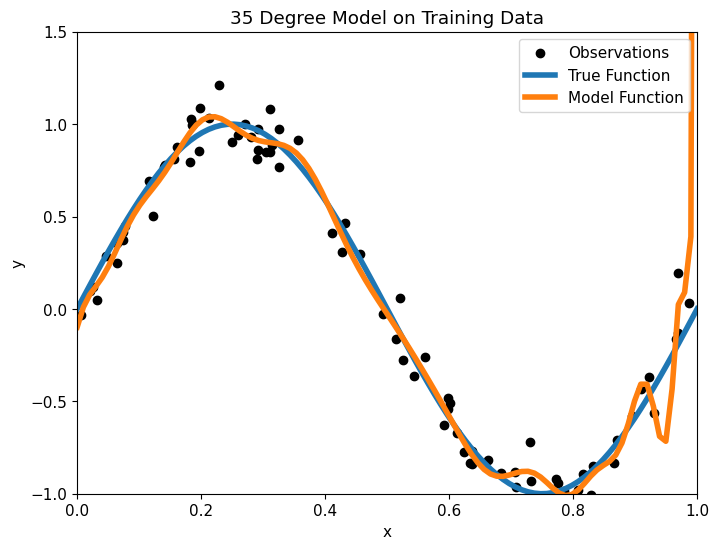

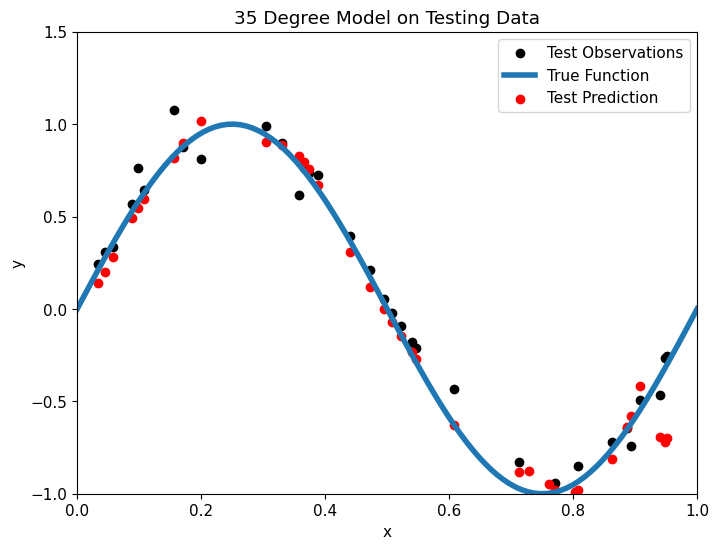

In [77]:
degrees = [1,2,3,7,10,20,25,30,35] 

for degree in degrees :
    fit_poly(train, y_train, test, y_test, degree = degree, plot = 'train') 
    fit_poly(train, y_train, test, y_test, degree = degree, plot = 'test')

In [78]:
degrees = [int(x) for x in np.linspace(1, 40, 40)] 
results = pd.DataFrame(columns = ['train_error', 'test_error'], index = degrees)
coefficients = [] 

# Try each value of degrees for the model and record results 
for degree in degrees: 
    degeree_results = fit_poly(train, y_train, test, y_test, degree = degree, plot = False, return_scores= True)
    results.loc[degree, 'train_error'] = degeree_results[0] 
    results.loc[degree, 'test_error'] = degeree_results[1]

    # store coefficients in a dictionary with degree 
    coefs = degeree_results[2] 
    coef_dict = {'degree': degree} 
    coef_dict.update({f'coef_{i}': coef for i , coef in enumerate(coefs)}) 
    coefficients.append(coef_dict) 

# convert the list of dictionaries to a DataFrame 
coefficients_df = pd.DataFrame(coefficients) 
coefficients_df.fillna(value=0, inplace=True) 
coefficients_df.set_index('degree', inplace=True) 
coefficients_df = coefficients_df.T 
#coefficients_df = coefficients_df.applymap(lambda x: f'{x: .2f}') 

In [79]:
results

,train_error,test_error
1,0.228933,0.153
2,0.228641,0.151413
3,0.010658,0.009581
4,0.010634,0.009351
5,0.008646,0.009666
6,0.008407,0.010392
7,0.00839,0.010618
8,0.008389,0.010609
9,0.008304,0.010754
10,0.00817,0.011321


In [80]:
desired_degrees = [1,2,3,5,10,20,25,30,35,40] 
coefficients_df[desired_degrees]

degree,1,2,3,5,10,20,25,30,35,40
coef_0,-1.897005,-1.664356,12.538397,7.764004,7.376655,-3.809063e+00,3.851445e+01,5.242411e+01,1.276211e+01,7.345449e+00
coef_1,0.000000,-0.239803,-36.128325,-2.957697,-58.586322,1.186190e+03,-2.246918e+03,-3.300905e+03,-1.464167e+02,2.892083e+02
coef_2,0.000000,0.000000,24.199141,-63.505763,987.757228,-6.073295e+04,7.052502e+04,1.073667e+05,-9.676636e+03,-2.600988e+04
coef_3,0.000000,0.000000,0.000000,97.941237,-7887.118765,1.648744e+06,-1.230148e+06,-1.955996e+06,5.046358e+05,8.502971e+05
coef_4,0.000000,0.000000,0.000000,-38.946750,32664.696255,-2.691966e+07,1.330252e+07,2.223620e+07,-1.018428e+07,-1.474192e+07
coef_5,0.000000,0.000000,0.000000,0.000000,-79709.500711,2.863451e+08,-9.533576e+07,-1.681185e+08,1.156746e+08,1.552900e+08
coef_6,0.000000,0.000000,0.000000,0.000000,119093.718231,-2.092016e+09,4.723338e+08,8.770007e+08,-8.285429e+08,-1.062541e+09
coef_7,0.000000,0.000000,0.000000,0.000000,-107004.528994,1.086821e+10,-1.659111e+09,-3.206549e+09,3.921015e+09,4.868525e+09
coef_8,0.000000,0.000000,0.000000,0.000000,53059.585322,-4.099958e+10,4.166893e+09,8.152976e+09,-1.236452e+10,-1.495037e+10
coef_9,0.000000,0.000000,0.000000,0.000000,-11153.319533,1.132460e+11,-7.356473e+09,-1.374157e+10,2.508217e+10,2.954254e+10


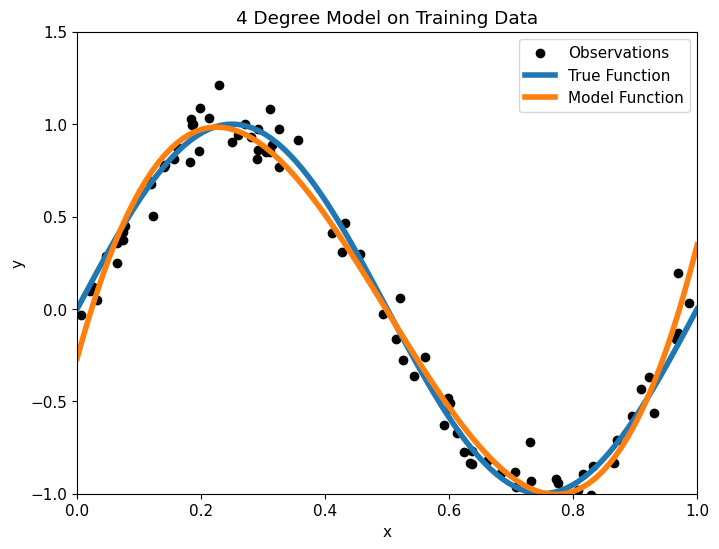

In [81]:
fit_poly(train, y_train, test, y_test, degree = 4, plot = 'train') 

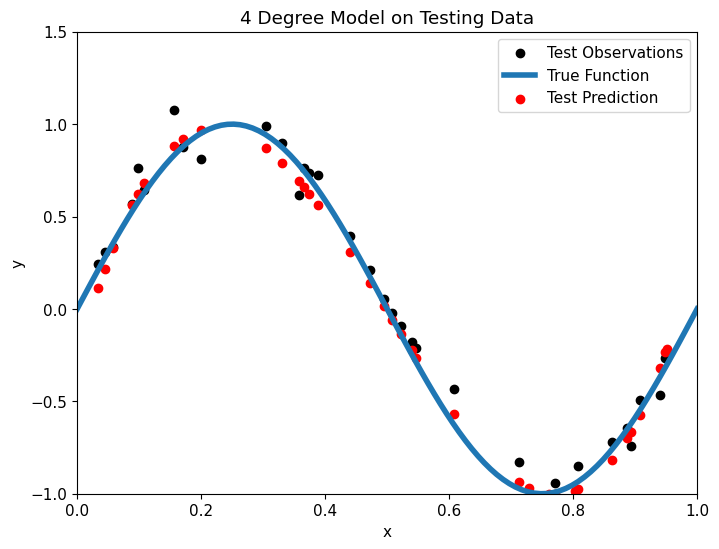

In [82]:
fit_poly(train, y_train, test, y_test, degree = 4, plot = 'test') 

In [83]:
print('10 Lowest training Error')
train_eval = results.sort_values('train_error').reset_index(level=0).rename(columns={'index': 'degrees'}) 
train_eval.loc[:, ['degrees','train_error']].head(10)


10 Lowest training Error


,degrees,train_error
0,36,0.006502
1,31,0.006504
2,32,0.006505
3,37,0.006506
4,33,0.006513
5,38,0.006514
6,34,0.006525
7,39,0.006525
8,35,0.006538
9,40,0.006538


In [84]:
print('10 Lowest testing Error')
test_eval = results.sort_values('test_error').reset_index(level=0).rename(columns={'index': 'degrees'}) 
test_eval.loc[:, ['degrees','test_error']].head(10)

10 Lowest testing Error


,degrees,test_error
0,4,0.009351
1,3,0.009581
2,5,0.009666
3,6,0.010392
4,8,0.010609
5,7,0.010618
6,9,0.010754
7,14,0.011216
8,10,0.011321
9,11,0.011342


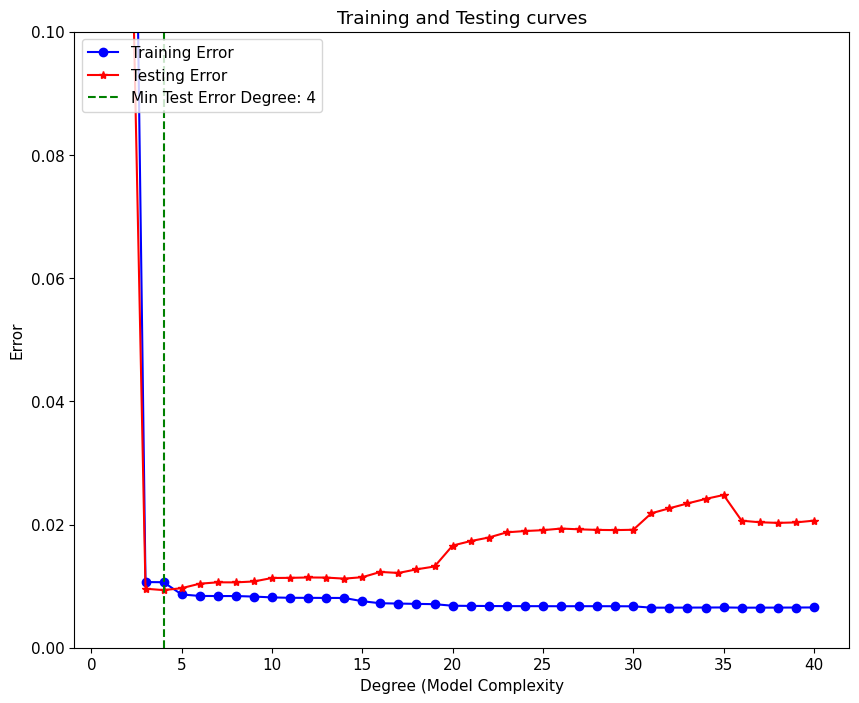


Minimum Training Error occurs at 35 degrees

Maximum Testing Error occurs at 4 degrees


In [88]:
plt.figure(figsize=(10,8)) 
plt.plot(results.index, results['train_error'], 'b-o', ms=6, label = 'Training Error') 
plt.plot(results.index, results['test_error'], 'r-*', ms=6, label = 'Testing Error') 

min_test_error_deg = results['test_error'].idxmin() 

plt.axvline(min_test_error_deg, color = 'green', linestyle= '--', label = f'Min Test Error Degree: {min_test_error_deg}') 
plt.legend(loc=2); plt.xlabel('Degree (Model Complexity'); plt.ylabel('Error'); plt.title('Training and Testing curves'); 
plt.ylim(0,0.10); plt.show()
print('\nMinimum Training Error occurs at {} degrees'.format(int(np.argmin(results['train_error']))))
print('\nMaximum Testing Error occurs at {} degrees'.format(results['test_error'].idxmin()))

# Bias Variance

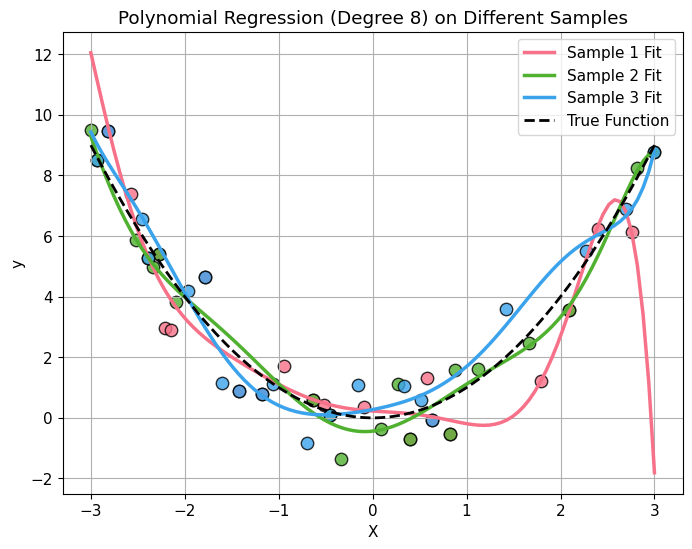

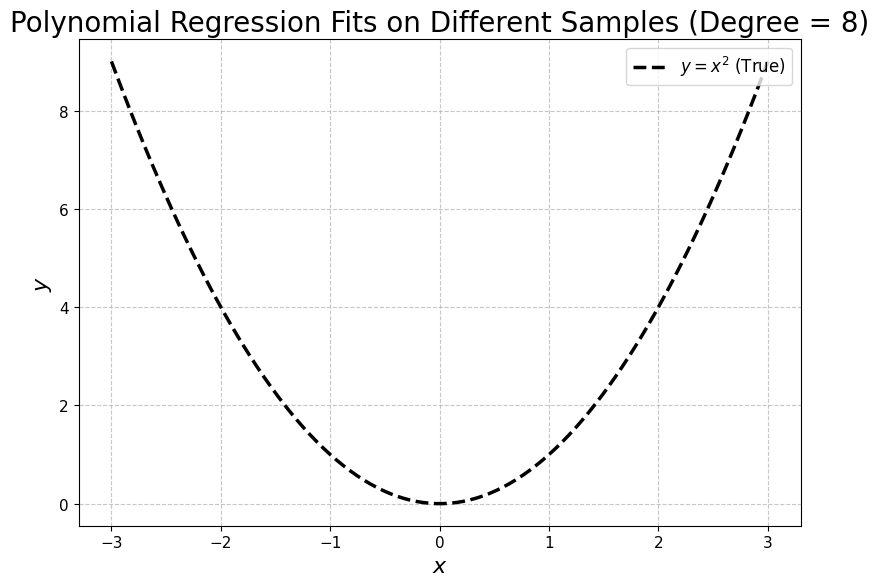

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Set seed
np.random.seed(42)

# Generate dataset (y = x^2 + noise)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = X**2 + np.random.normal(scale=1.0, size=X.shape)

# Parameters
num_samples = 3
sample_size = 20

# Colors
colors = sns.color_palette("husl", num_samples)

plt.figure(figsize=(8, 6))

# Loop over different samples
for i in range(num_samples):
    # Randomly select indices
    indices = np.random.choice(range(len(X)), size=sample_size, replace=False)
    
    X_sample = X[indices]
    y_sample = y[indices]
    
    # Polynomial transformation (degree 8)
    poly = PolynomialFeatures(degree=8)
    X_poly_sample = poly.fit_transform(X_sample)
    X_poly = poly.transform(X)
    
    # Train model
    model = LinearRegression()
    model.fit(X_poly_sample, y_sample)
    
    # Predict
    y_pred = model.predict(X_poly)
    
    # Plot sample points
    plt.scatter(X_sample, y_sample, color=colors[i], s=80, alpha=0.8, edgecolor='black')
    
    # Plot fitted curve
    plt.plot(X, y_pred, color=colors[i], linewidth=2.5, label=f'Sample {i+1} Fit')

# Plot true function
plt.plot(X, X**2, color='black', linestyle='--', linewidth=2, label='True Function')


plt.title("Polynomial Regression (Degree 8) on Different Samples")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
# Plot the true function (y = x^2)
plt.plot(X, X**2, color='black', linestyle='--',
         linewidth=2.5, label=r"$y = x^2$ (True)")

# Labels and title
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)

plt.title(r"Polynomial Regression Fits on Different Samples (Degree = 8)",
          fontsize=20)

# Legend
plt.legend(loc="upper right", fontsize=12)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display plot
plt.show()

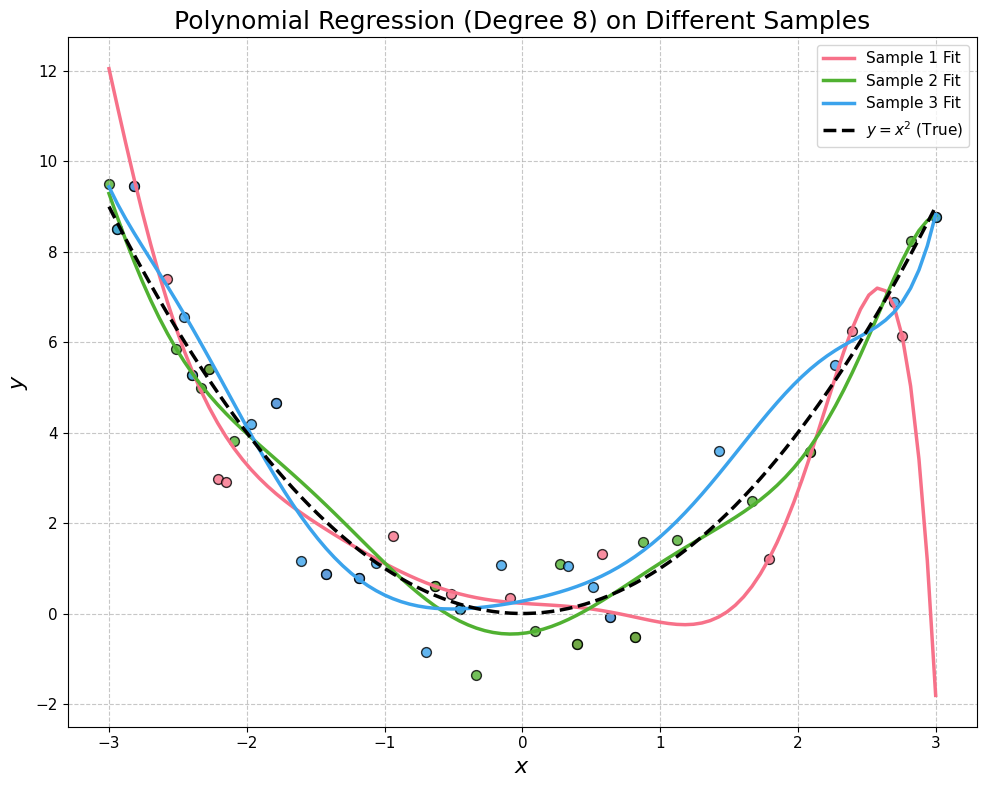

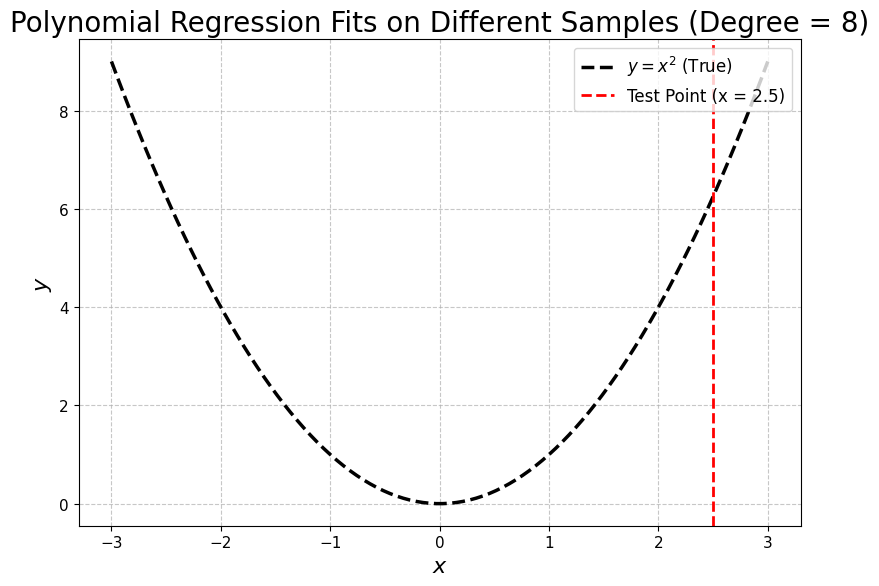

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Set seed
np.random.seed(42)

# Generate dataset (y = x^2 + noise)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = X**2 + np.random.normal(scale=1.0, size=X.shape)

# Parameters
num_samples = 3
sample_size = 20

# Colors
colors = sns.color_palette("husl", num_samples)

plt.figure(figsize=(10, 8))

# Train polynomial regression on different samples
for i in range(num_samples):
    
    # Random sampling
    indices = np.random.choice(range(len(X)), size=sample_size, replace=False)
    
    X_sample = X[indices]
    y_sample = y[indices]
    
    # Model: Polynomial Regression (degree 8)
    model = make_pipeline(
        PolynomialFeatures(degree=8),
        LinearRegression()
    )
    
    model.fit(X_sample, y_sample)
    
    # Prediction on full data
    y_pred = model.predict(X)
    
    # Plot sample points
    plt.scatter(X_sample, y_sample,
                color=colors[i], s=50, alpha=0.8, edgecolor='black')
    
    # Plot fitted curve
    plt.plot(X, y_pred,
             color=colors[i], linewidth=2.5,
             label=f'Sample {i+1} Fit')

# Plot true function
plt.plot(X, X**2, color='black', linestyle='--',
         linewidth=2.5, label=r"$y = x^2$ (True)")

# Labels and styling
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)
plt.title("Polynomial Regression (Degree 8) on Different Samples", fontsize=18)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
# Plot the true function (reference)
plt.plot(X, X**2, color='black', linestyle='--',
         linewidth=2.5, label=r"$y = x^2$ (True)")

# Define a test point
test_point = 2.5

# Plot vertical line at test point
plt.axvline(x=test_point, color='red', linestyle='--',
            linewidth=2, label=f'Test Point (x = {test_point})')

# Labels and title
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)

plt.title("Polynomial Regression Fits on Different Samples (Degree = 8)",
          fontsize=20)

# Legend
plt.legend(loc='upper right', fontsize=12)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

In [91]:

# Functions to Calculate Bias and Variance
# Code
# Markdown
def calculate_bias_variance(train, y_train, test, y_test, degree, n_iterations=100, random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)  # Set the random seed

    # Reshape train and test data
    train = train.reshape(-1, 1)
    test = test.reshape(-1, 1)

    # outside the loop
    # Transform train and test data once
    features = PolynomialFeatures(degree=degree, include_bias=False)
    train_transformed = features.fit_transform(train)
    test_transformed = features.transform(test)

    all_predictions_train = np.zeros((n_iterations, len(train)))
    all_predictions_test = np.zeros((n_iterations, len(test)))

    for i in range(n_iterations):

        # Resample the training data
        indices = np.random.choice(len(train), len(train), replace=True)
        train_resample_trans = train_transformed[indices]
        y_train_resample = y_train[indices]

        # Fit the model on the resampled training data
        model = LinearRegression().fit(train_resample_trans, y_train_resample)

        # Predict on the original train and test sets
        all_predictions_train[i] = model.predict(train_transformed).flatten()
        all_predictions_test[i] = model.predict(test_transformed).flatten()

    # Bias Calculation
    avg_pred_train = np.mean(all_predictions_train, axis=0)
    avg_pred_test = np.mean(all_predictions_test, axis=0)

    bias_train = np.mean((avg_pred_train - y_train.flatten())**2)
    bias_test = np.mean((avg_pred_test - y_test.flatten())**2)

    # Variance calculation
    variance_train = np.mean(np.var(all_predictions_train, axis=0))
    variance_test = np.mean(np.var(all_predictions_test, axis=0))

    # MSE Calculation
    mse_train = bias_train + variance_train
    mse_test = bias_test + variance_test

    return {
        "bias_train": bias_train,
        "variance_train": variance_train,
        "mse_train": mse_train,
        "bias_test": bias_test,
        "variance_test": variance_test,
        "mse_test": mse_test
    }

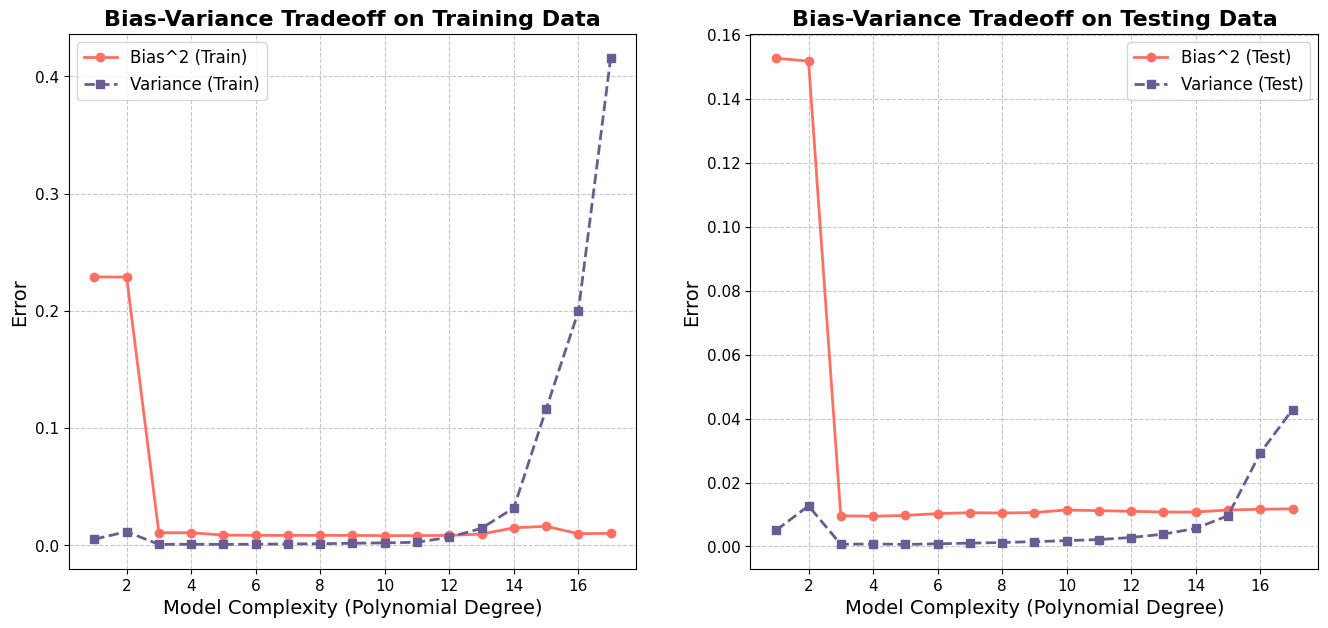

In [92]:


def plot_bias_variance(train, y_train, test, y_test, max_degree=15, n_iterations=100, random_seed=None):
    
    biases_train, variances_train, biases_test, variances_test = [], [], [], []
    
    degrees = range(1, max_degree + 1)
    
    for degree in degrees:
        results = calculate_bias_variance(
            train, y_train, test, y_test,
            degree,
            n_iterations=n_iterations,
            random_seed=random_seed
        )
        
        biases_train.append(results['bias_train'])
        variances_train.append(results['variance_train'])
        biases_test.append(results['bias_test'])
        variances_test.append(results['variance_test'])

    plt.figure(figsize=(14, 7))

    # Custom color palette
    color_bias = '#FF6F61'
    color_variance = '#6B5B95'

    # Plot for Training Data
    plt.subplot(1, 2, 1)
    plt.plot(degrees, biases_train, label="Bias^2 (Train)", color=color_bias,
             marker='o', linestyle='-', linewidth=2, markersize=6)
    plt.plot(degrees, variances_train, label='Variance (Train)', color=color_variance,
             marker='s', linestyle='--', linewidth=2, markersize=6)

    plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=14)
    plt.ylabel("Error", fontsize=14)
    plt.title("Bias-Variance Tradeoff on Training Data", fontsize=16, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)

    # Plot for Testing Data
    plt.subplot(1, 2, 2)
    plt.plot(degrees, biases_test, label="Bias^2 (Test)", color=color_bias,
             marker='o', linestyle='-', linewidth=2, markersize=6)
    plt.plot(degrees, variances_test, label='Variance (Test)', color=color_variance,
             marker='s', linestyle='--', linewidth=2, markersize=6)

    plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=14)
    plt.ylabel("Error", fontsize=14)
    plt.title("Bias-Variance Tradeoff on Testing Data", fontsize=16, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)

    # Adjust layout for better spacing
    plt.tight_layout(pad=3.0)
    plt.show()


# Example usage:
plot_bias_variance(train, y_train, test, y_test, max_degree=17, n_iterations=100, random_seed=42)

In [93]:
print('Thank You')

Thank You
